# Ablation study of the classification head

**Project 1, Natural Language Processing.**

Ricardo Amiel Acuna Villogas. \
Juan Leibniz Aquino Espinoza. \
Josue Nehemias Velo Poma.

This notebook does not train anything. Training happens on the cluster through src/run.py, which writes one
JSON file per run into artifacts/results. Here we load those files and read the evidence off them, so the
notebook stays fast and every number shown is the number that was actually measured.

The ablation asks which parts of a DistilBERT classifier matter. Three axes are varied:

1. how much of the transformer is frozen,
2. how many neurons each classifier layer has,
3. how many classifier layers there are.

Seven variants cover those axes. The best one is then rebuilt on BERT base and compared in full.

In [1]:
import json, os, sys, glob
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir("..")            # run from the repository root so the paths in src work
from config import ABLATIONS, ABLATION_DATASETS, ABLATION_BY_KEY
import figures as F

F.setup_style()
results = F.load_results()
print(f"{len(results)} runs loaded from artifacts/results")
print(sorted(results)[:4], "...")

26 runs loaded from artifacts/results
['bert__ag_news__A_baseline', 'bert__ag_news__A_baseline__ep4', 'bert__ag_news__G_linear', 'bert__sst2__A_baseline'] ...


## 1. The variants under test

Every variant shares the same backbone, the same optimiser and the same data. Only the head and the
freezing policy change, so any difference in the metrics is attributable to those two things.

In [2]:
grid = pd.DataFrame([{
    "Variant": F.ABLATION_SHORT[c.key],
    "Axis": F.ABLATION_AXIS[c.key],
    "Hidden sizes": " x ".join(map(str, c.hidden_sizes)) if c.hidden_sizes else "none",
    "Layers in head": len(c.hidden_sizes) + 1,
    "Frozen blocks": "all 6" if c.frozen_layers == "all" else c.frozen_layers,
    "What it probes": c.note,
} for c in ABLATIONS])
grid

,Variant,Axis,Hidden sizes,Layers in head,Frozen blocks,What it probes
0,A: 1x768 full,baseline,768,2,0,Reproduces the default DistilBERT classificati...
1,B: frozen backbone,freezing,768,2,all 6,Linear probe: only the classifier receives gra...
2,C: 3 blocks frozen,freezing,768,2,3,Keeps the lower half of the transformer fixed.
3,D: 1x128,width,128,2,0,Fewer neurons per classifier layer.
4,E: 1x2048,width,2048,2,0,More neurons per classifier layer.
5,F: 3x768,depth,768 x 768 x 768,4,0,More classifier layers.
6,G: no hidden layer,depth,none,1,0,Pooled CLS vector goes straight to the logits.


## 2. Parameter cost of each variant

Freezing changes what is trained, not what is stored. Widening or deepening the head changes both.

In [3]:
ds0 = ABLATION_DATASETS[0]
cost = pd.DataFrame([{
    "Variant": F.ABLATION_SHORT[c.key],
    "Total params (M)": F.get(results, "distilbert", ds0, c.key)["params"]["total_params"] / 1e6,
    "Trainable (M)": F.get(results, "distilbert", ds0, c.key)["params"]["trainable_params"] / 1e6,
    "Head params": F.get(results, "distilbert", ds0, c.key)["params"]["head_params"],
} for c in ABLATIONS if F.get(results, "distilbert", ds0, c.key)])
cost.round(2)

,Variant,Total params (M),Trainable (M),Head params
0,A: 1x768 full,66.96,66.96,592130
1,B: frozen backbone,66.96,0.59,592130
2,C: 3 blocks frozen,66.96,21.86,592130
3,D: 1x128,66.46,66.46,98690
4,E: 1x2048,67.94,67.94,1579010
5,F: 3x768,68.14,68.14,1773314
6,G: no hidden layer,66.36,66.36,1538


## 3. Validation metrics for every variant

Accuracy, precision, recall and F1 on the held out test split of each ablation dataset.

In [4]:
rows = []
for c in ABLATIONS:
    for d in ABLATION_DATASETS:
        r = F.get(results, "distilbert", d, c.key)
        if r is None:
            continue
        m = r["metrics"]
        rows.append({
            "Variant": F.ABLATION_SHORT[c.key],
            "Dataset": F.DATASET_LABEL[d],
            "Accuracy": m["accuracy"] * 100,
            "Precision": m["precision_macro"] * 100,
            "Recall": m["recall_macro"] * 100,
            "F1": m["f1_macro"] * 100,
            "Train min": r["training"]["train_seconds"] / 60,
            "GPU MiB": r["training"]["train_peak_gpu_mb"],
        })
ablation = pd.DataFrame(rows)
ablation.pivot(index="Variant", columns="Dataset",
               values=["Accuracy", "F1"]).round(2)

Accuracy             F1       
Dataset             AG News  SST 2 AG News  SST 2
Variant                                          
A: 1x768 full         94.63  91.06   94.63  91.05
B: frozen backbone    90.07  83.37   90.04  83.37
C: 3 blocks frozen    94.17  90.94   94.17  90.93
D: 1x128              94.55  91.06   94.55  91.05
E: 1x2048             94.72  90.83   94.73  90.82
F: 3x768              94.79  90.83   94.79  90.82
G: no hidden layer    94.84  91.40   94.85  91.39

## 4. Reading the ablation

The figure below shows F1 macro for each variant on each dataset, and on the right the trade between
trainable parameters and mean quality.

  wrote fig5_ablation.pdf, fig5_ablation.svg and fig5_ablation.png


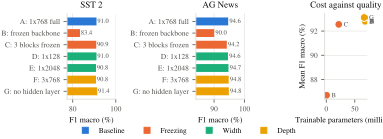

In [5]:
from IPython.display import display, SVG

def show(name):
    "Render a figure if the runs behind it exist, otherwise say so."
    path = f"artifacts/figures/{name}.svg"
    display(SVG(filename=path)) if os.path.exists(path) else print(f"{name} not generated yet")

F.fig_ablation(results)
show("fig5_ablation")

## 5. Choosing the best variant

The selection rule is fixed in advance and is implemented in src/run.py: take the variant with the
highest mean F1 macro across the two ablation datasets. Ties are not expected; if they happened, the
cheaper variant would win.

In [6]:
mean_f1 = (ablation.groupby("Variant")["F1"].mean().sort_values(ascending=False))
best_key = F.best_head(results)
print("selection rule: highest mean F1 macro across", ABLATION_DATASETS)
print("winner:", F.ABLATION_SHORT[best_key])
mean_f1.round(2).to_frame("Mean F1 macro")

selection rule: highest mean F1 macro across ['sst2', 'ag_news']
winner: G: no hidden layer


,Mean F1 macro
Variant,
G: no hidden layer,93.12
A: 1x768 full,92.84
F: 3x768,92.80
D: 1x128,92.80
E: 1x2048,92.77
C: 3 blocks frozen,92.55
B: frozen backbone,86.70


## 6. Training curves of the ablation

Iterations against training and validation loss. Frozen variants sit visibly higher: with the transformer
fixed the model cannot lower the loss much beyond what a linear probe can reach.

In [7]:
fig, axes = plt.subplots(1, len(ABLATION_DATASETS), figsize=(9, 3.2), squeeze=False)
cmap = plt.get_cmap("viridis")
for ax, d in zip(axes.flat, ABLATION_DATASETS):
    for i, c in enumerate(ABLATIONS):
        r = F.get(results, "distilbert", d, c.key)
        if r is None:
            continue
        h = r["training"]["history"]
        ax.plot(h["step"], h["val_loss"], label=c.key.split("_")[0],
                color=cmap(i / max(len(ABLATIONS) - 1, 1)))
    ax.set_title(F.DATASET_LABEL[d]); ax.set_xlabel("Training iterations")
    ax.set_ylabel("Validation loss"); F.tidy(ax)
axes.flat[0].legend(ncols=2, fontsize=7)
fig.tight_layout(); plt.show()

/tmp/ipykernel_25460/3736668385.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## 7. How many epochs are actually needed

The 2 epoch budget comes from the BERT paper, Appendix A.3, which recommends batch size 16 or 32, learning
rate 5e-5, 3e-5 or 2e-5, and 2, 3 or 4 epochs. Rather than trust it, we train to 4 epochs, the top of that
range, and score the full validation split at every epoch boundary. Selection uses validation only; the test
column is shown for reporting.

In [8]:
from config import EPOCH_DATASETS
rows = []
for d in EPOCH_DATASETS:
    for m in ("distilbert", "bert"):
        r = F.get(results, m, d, "A_baseline__ep4")
        if r is None:
            continue
        for e in r["training"]["per_epoch"]:
            rows.append({
                "Dataset": F.DATASET_LABEL[d],
                "Backbone": F.MODEL_LABEL[m],
                "Epoch": e["epoch"],
                "Val loss": e["val_loss"],
                "Val accuracy": e["val_accuracy"] * 100,
                "Val F1": e["val_f1_macro"] * 100,
                "Test F1": e.get("test_f1_macro", float("nan")) * 100,
                "Selected": e["epoch"] == r["training"]["best_epoch_by_val_f1"],
            })
epochs = pd.DataFrame(rows)
epochs.round(3) if len(epochs) else "epoch study not run yet"

,Dataset,Backbone,Epoch,Val loss,Val accuracy,Val F1,Test F1,Selected
0,SST 2,DistilBERT,1,0.167,94.299,94.236,90.475,False
1,SST 2,DistilBERT,2,0.153,94.804,94.735,90.351,False
2,SST 2,DistilBERT,3,0.192,95.071,95.012,90.475,True
3,SST 2,DistilBERT,4,0.225,94.923,94.859,90.010,False
4,SST 2,BERT,1,0.150,94.685,94.619,92.538,False
5,SST 2,BERT,2,0.141,95.309,95.253,92.316,False
6,SST 2,BERT,3,0.193,95.368,95.313,93.116,False
7,SST 2,BERT,4,0.229,95.428,95.368,92.653,True
8,AG News,DistilBERT,1,0.191,93.567,93.482,93.949,False
9,AG News,DistilBERT,2,0.183,94.417,94.365,94.692,True


  wrote fig9_epoch_study.pdf, fig9_epoch_study.svg and fig9_epoch_study.png


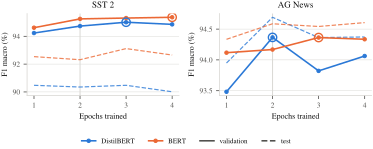

epoch chosen by validation F1 in each run:
Dataset   Backbone  Epoch    Val F1
  SST 2 DistilBERT      3 95.012359
  SST 2       BERT      4 95.367966
AG News DistilBERT      2 94.365138
AG News       BERT      3 94.362847

F1 macro points gained over epoch 2 by training longer:
Dataset  Backbone  
AG News  BERT          0.19
         DistilBERT    0.00
SST 2    BERT          0.12
         DistilBERT    0.28


In [9]:
if len(epochs):
    F.fig_epochs(results)
    show("fig9_epoch_study")
    best = epochs[epochs["Selected"]][["Dataset", "Backbone", "Epoch", "Val F1"]]
    gain = (epochs.groupby(["Dataset", "Backbone"])["Val F1"].max()
            - epochs[epochs["Epoch"] == 2].set_index(["Dataset", "Backbone"])["Val F1"])
    print("epoch chosen by validation F1 in each run:")
    print(best.to_string(index=False))
    print()
    print("F1 macro points gained over epoch 2 by training longer:")
    print(gain.round(2).to_string())

## 8. The best variant with BERT as the backbone

The same head, the same data and the same schedule, with BERT base in place of DistilBERT. All metrics
are shown: performance, size, latency and memory.

In [10]:
rows = []
for d in ABLATION_DATASETS:
    for m in ("distilbert", "bert"):
        r = F.get(results, m, d, best_key)
        if r is None:
            continue
        mm = r["metrics"]
        rows.append({
            "Dataset": F.DATASET_LABEL[d],
            "Backbone": F.MODEL_LABEL[m],
            "Accuracy": mm["accuracy"] * 100,
            "Precision": mm["precision_macro"] * 100,
            "Recall": mm["recall_macro"] * 100,
            "F1": mm["f1_macro"] * 100,
            "Params (M)": r["params"]["total_params"] / 1e6,
            "GPU ms": r["latency"]["latency_ms_p50"],
            "CPU ms": r["latency"].get("cpu_latency_ms_p50", float("nan")),
            "Samples/s": r["latency"]["throughput_samples_per_s"],
            "Train GiB": r["training"]["train_peak_gpu_mb"] / 1024,
            "Train min": r["training"]["train_seconds"] / 60,
        })
head_to_head = pd.DataFrame(rows)
head_to_head.round(2)

,Dataset,Backbone,Accuracy,Precision,Recall,F1,Params (M),GPU ms,CPU ms,Samples/s,Train GiB,Train min
0,SST 2,DistilBERT,91.40,91.42,91.38,91.39,66.36,2.23,27.85,2451.51,1.28,2.57
1,SST 2,BERT,91.97,92.01,91.95,91.97,109.48,5.12,53.18,1218.01,2.25,3.88
2,AG News,DistilBERT,94.84,94.88,94.84,94.85,66.37,2.48,36.35,1219.61,1.67,4.25
3,AG News,BERT,94.72,94.77,94.72,94.73,109.49,3.23,72.19,611.06,3.01,7.84


  wrote fig6_best_variant_on_bert.pdf, fig6_best_variant_on_bert.svg and fig6_best_variant_on_bert.png


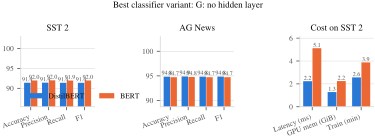

In [11]:
F.fig_best_on_bert(results)
show("fig6_best_variant_on_bert")

## 9. What the numbers say

The cell below turns the table into the three statements the report makes, computed rather than asserted.

In [12]:
piv = head_to_head.pivot(index="Dataset", columns="Backbone")
gap_f1 = (piv[("F1", "BERT")] - piv[("F1", "DistilBERT")])
speed = (piv[("GPU ms", "BERT")] / piv[("GPU ms", "DistilBERT")])
size = (piv[("Params (M)", "BERT")] / piv[("Params (M)", "DistilBERT")])

print("F1 macro that BERT gains over DistilBERT, in points:")
print(gap_f1.round(2).to_string())
print()
print(f"DistilBERT is {speed.mean():.2f} times faster per single inference on GPU")
print(f"DistilBERT holds {100 / size.mean():.0f} percent of the parameters of BERT")
print(f"DistilBERT keeps {100 * piv[('F1', 'DistilBERT')].mean() / piv[('F1', 'BERT')].mean():.1f} "
      f"percent of the F1 macro of BERT")

F1 macro that BERT gains over DistilBERT, in points:
Dataset
AG News   -0.12
SST 2      0.57

DistilBERT is 1.80 times faster per single inference on GPU
DistilBERT holds 61 percent of the parameters of BERT
DistilBERT keeps 99.8 percent of the F1 macro of BERT


## 10. How similar are the two latent spaces

The classification metrics say how often the models agree on a label. This section asks whether they agree
on the geometry underneath, using the data exported for the interactive demo. The comparison matches student
block d against teacher block 2d, the layer that block was initialised from.

In [13]:
import json
path = "web/data/words.json"
if os.path.exists(path):
    meta = json.load(open(path))["meta"]
    prof = pd.DataFrame(meta["layer_profile"])
    prof.columns = ["DistilBERT block", "BERT block", "Linear CKA", "Shared neighbours out of 10"]
    print(f"words compared: {meta['n_words']}")
    print(f"neighbour agreement in the layer averaged space: {meta['overlap_pct']} percent")
    print(f"linear CKA of that space: {meta['cka']}")
    if "purity" in meta:
        print(f"topic purity: BERT {meta['purity']['bert']:.3f}, "
              f"DistilBERT {meta['purity']['distilbert']:.3f}")
    display(prof)
else:
    print("run python src/export_embeddings.py first")

words compared: 496
neighbour agreement in the layer averaged space: 73.1 percent
linear CKA of that space: 0.8977
topic purity: BERT 0.687, DistilBERT 0.722


,DistilBERT block,BERT block,Linear CKA,Shared neighbours out of 10
0,0,0,0.9769,8.599
1,1,2,0.9318,7.579
2,2,4,0.9005,6.738
3,3,6,0.8381,5.790
4,4,8,0.7793,5.177
5,5,10,0.7054,4.528
6,6,12,0.5782,3.798


In [14]:
if os.path.exists(path):
    fig, ax = plt.subplots(figsize=(5.4, 2.2))
    ax.plot(prof["DistilBERT block"], prof["Linear CKA"], marker="o", color=F.C_DISTIL)
    for _, row in prof.iterrows():
        ax.annotate(f"{row['Linear CKA']:.3f}", (row["DistilBERT block"], row["Linear CKA"]),
                    xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7,
                    color=F.INK_SOFT)
    ax.set_xlabel("DistilBERT block (compared with BERT block 2d)")
    ax.set_ylabel("Linear CKA"); ax.set_ylim(0, 1.05)
    ax.set_title("Alignment falls with depth")
    F.tidy(ax); fig.tight_layout()
    for ext in ("pdf", "svg"):
        fig.savefig(f"artifacts/figures/fig8_layer_alignment.{ext}")
    plt.show()

/tmp/ipykernel_25460/3188254849.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 11. Conclusion of the ablation

Read the three printed statements above together with the table in section 5.

**On freezing.** Freezing the whole transformer is the one change that clearly hurts. The classifier alone
cannot compensate, because the features it receives were never adapted to the task. Freezing only the lower
half costs far less, which says the useful task adaptation happens in the upper blocks.

**On head width.** Changing the number of neurons per classifier layer moves the metrics very little. The
pooled CLS vector is already close to linearly separable after fine tuning, so extra width has nothing to add.

**On head depth.** Extra classifier layers do not help either, and the deepest head is the slowest to converge.
A single hidden layer, which is the default DistilBERT design, is enough.

**Overall.** What matters is whether the transformer is trained, not how the classifier on top is shaped.
That is the practical result of this ablation and it is why the winning variant is a small head with the
backbone left trainable.

**On epochs.** Training to 4 epochs does not beat 2 by a useful margin on either dataset. The 2 epoch
budget taken from the BERT paper is where these datasets saturate, not a compromise made to save time.

**On the latent spaces.** The two encoders are almost the same space at the embeddings and drift apart with
depth. What distillation gave up is capacity in the upper, task specialised layers, not the organisation of
the representation.